#### **ANÁLISIS EXPLORATORIO DE DATOS (EDA)**

In [60]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

catalogo_productos = pd.read_csv("Datos-finales/catalogo_productos.csv")
especificaciones_cajas = pd.read_csv("Datos-finales/especificaciones_cajas.csv")
operaciones_planta = pd.read_csv("Datos-finales/operaciones_planta.csv")
procurement_cajas = pd.read_csv("Datos-finales/procurement_cajas.csv")

#### **1. Estadísticas de productos**

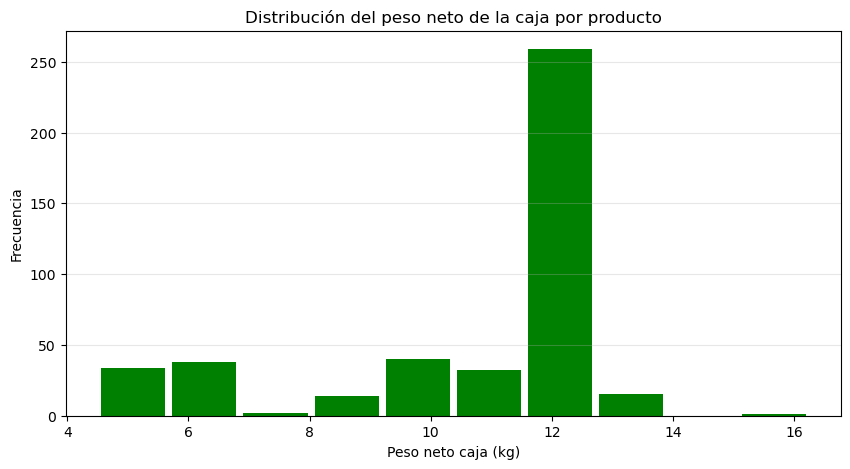

In [61]:
plt.figure(figsize=(10, 5))
plt.hist(catalogo_productos['peso_neto_caja'].dropna(), bins=10,
         color='green', rwidth=0.9)
plt.title('Distribución del peso neto de la caja por producto')
plt.xlabel('Peso neto caja (kg)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

#### **2. Estadísticas de cajas**

In [62]:
print("TOP 5 tipos de cajas con más utilización de pallet")
print("-" * 55)
top_pallet = especificaciones_cajas.groupby('caja_tipo_id')['utilizacion'].mean().nlargest(5)
print(top_pallet)

print("\nTOP 5 tipos de cajas con menos utilización de pallet")
print("-" * 55)
worst_pallet = especificaciones_cajas.groupby('caja_tipo_id')['utilizacion'].mean().nsmallest(5)
print(worst_pallet)

TOP 5 tipos de cajas con más utilización de pallet
-------------------------------------------------------
caja_tipo_id
bd62436e72b572461e548cf6e4bfdd7d    0.986888
b2a1bd10e103dae56072fe8ba4f0ca15    0.977213
e0f0d757e0995cc6d8f42ce6a520228e    0.976620
45d3118bfae802ddfa0399a8135c2361    0.976183
42df43cac5362b6b332e67057aac0554    0.975856
Name: utilizacion, dtype: float64

TOP 5 tipos de cajas con menos utilización de pallet
-------------------------------------------------------
caja_tipo_id
1d53cb238c8997b85dde2badf022947f    0.717528
7d5bf7157bac4cddab76a52a1d8dd41d    0.723668
f5bd804a90f4512d522129ccb62d549f    0.734352
4a996ddd03e81fc2dbda07eb0ca1135d    0.737715
c8898fc66f1c4e56f02718e10a4dc36b    0.743923
Name: utilizacion, dtype: float64


In [63]:
cajas_usadas = catalogo_productos['caja_tipo_id'].value_counts()
especificaciones_cajas['num_productos'] = especificaciones_cajas['caja_tipo_id'].map(
    cajas_usadas
)

print("TOP 5 tipos de cajas con más número de productos")
print("-" * 55)
top_num_prod = especificaciones_cajas.groupby('caja_tipo_id')['num_productos'].mean().nlargest(5)
print(top_num_prod)


TOP 5 tipos de cajas con más número de productos
-------------------------------------------------------
caja_tipo_id
ef0525f0911fd36073c2b10f4d81dfd5    11.0
dbb291248e849bc6807762eb48e5f5cf     8.0
6ecff7742d4a01e1ada1f078a109ba73     7.0
bee1ee50d857c700c72bb718c6f645db     7.0
c8c092bbf8da5f80452c66c38d27305f     7.0
Name: num_productos, dtype: float64


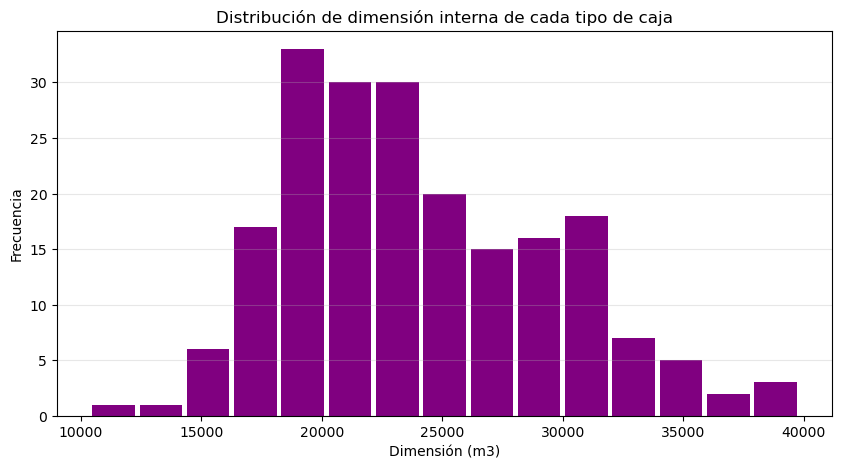

In [64]:
cajas_dimension = especificaciones_cajas['dimension_interna'] / 1000
plt.figure(figsize=(10, 5))
plt.hist(cajas_dimension.dropna(), bins=15,
         color='purple', rwidth=0.9)
plt.title('Distribución de dimensión interna de cada tipo de caja')
plt.xlabel('Dimensión (m3)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

Entender cómo se distribuye la dimensión interna de cada tipo de caja es crucial en el problema.

Como la diferencia entre la dimensión interna original y la nueva no puede excederse de 10%, solamente podemos reelegir para cada producto un tipo de caja con dimensión similar al anterior. Esto nos restringe claramente la cantidad de tipos de caja que podemos utilizar para cada producto.

#### **3. Utilización de caja y pallet**

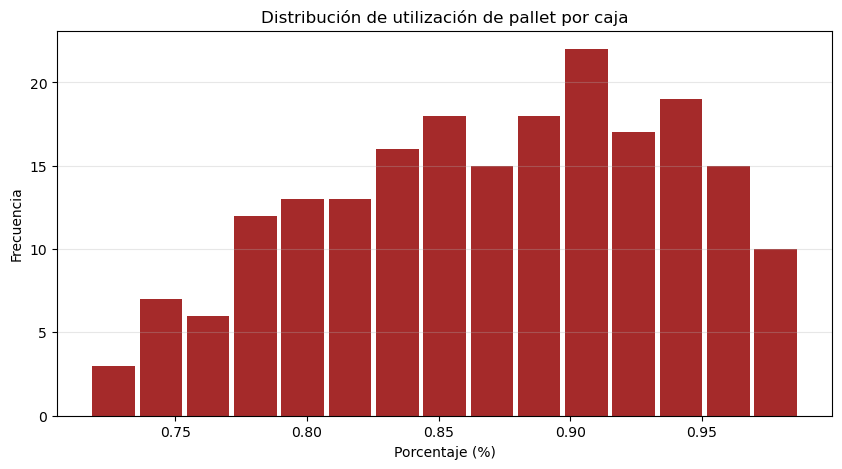

In [65]:
plt.figure(figsize=(10, 5))
plt.hist(especificaciones_cajas['utilizacion'].dropna(), bins=15,
         color='brown', rwidth=0.9)
plt.title('Distribución de utilización de pallet por caja')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

Notemos que de los 204 tipos de cajas, la mayoría realmente no tiene un uso eficiente del espacio de pallet. Si bien vemos que algunos ocupan en un 90% o más, hay otros que apenas alcanzan al 75%; y la mitad alternan entre un 80% y 90%, lo cual demuestra que el uso de ciertos tipos de cajas se ve más beneficiado que de otros.

#### **4. Volumen de productos y cajas por planta**

In [66]:
def resumen_por_planta(df, prefijo, titulo):
    cols = [c for c in df.columns if c.startswith(prefijo)] # Filtramos por las plantas
    sums = {}
    for c in cols:
        vals = pd.to_numeric(df[c], errors='coerce').fillna(0)
        sums[c.replace(prefijo, '')] = vals.sum() # Sumamos cada volumen de producto/caja
    
    serie = pd.Series(sums).sort_values(ascending=False) # Sorteamos de mayor a menor
    
    # Imprimimos la información
    print(titulo)
    print("-" * 35)
    for planta, total in serie.items():
        print(f"{planta:15s} {total:12}")

resumen_por_planta(operaciones_planta, 'volumen_producto_planta_', "Productos enviados por planta")
print("\n")
resumen_por_planta(procurement_cajas, 'volumen_tipo_planta_', "Cajas enviadas por planta")

Productos enviados por planta
-----------------------------------
curitiba            24919776
santiago            16349368
buenos_aires        10944695
bakersfield          9694072
monterrey            8207855


Cajas enviadas por planta
-----------------------------------
curitiba           106682302
santiago            71075654
monterrey           45648038
bakersfield         41373865
buenos_aires        32902485


Observemos que las plantas de Curitiba y Santiago son las que reciben más productos y cajas en general. En el caso de Curitiba, la diferencia supera el doble frente a las demás tres plantas. Esto puede suponer una mayor conveniencia para enviar unidades a Curitiba, debido a los altos descuentos en el costo.

Veamos en más profundidad la variación de descuentos según la planta.

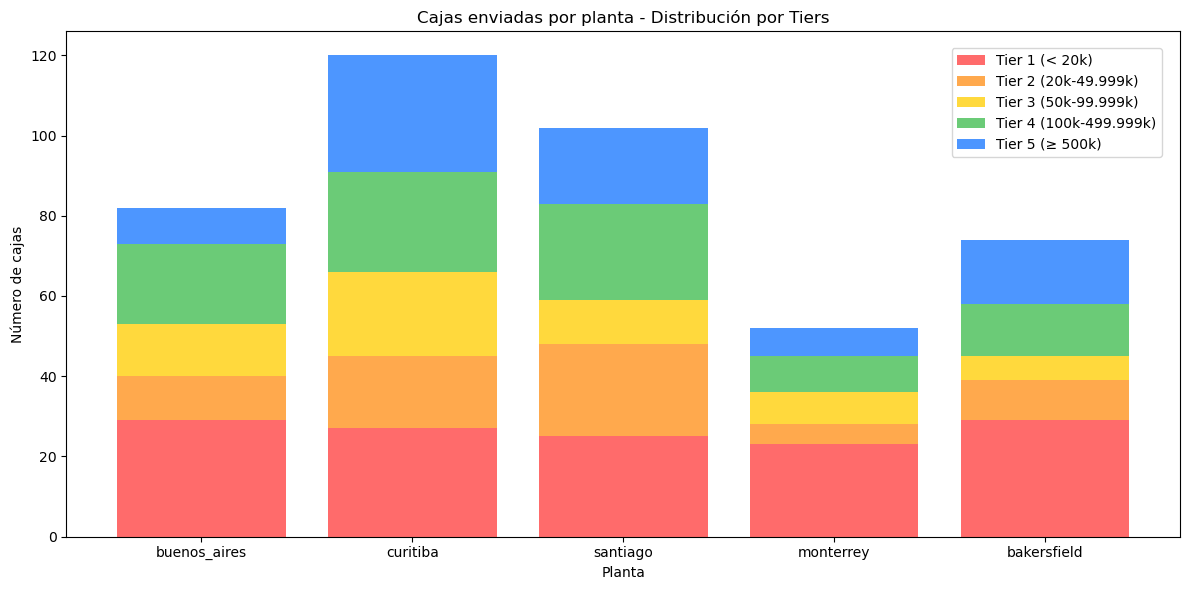

In [67]:
def clasificar_tier(volumen):
    """ Clasifica el volumen en tiers según las reglas definidas. """
    if volumen < 20000:
        return 'Tier 1 (< 20k)'
    elif volumen < 50000:
        return 'Tier 2 (20k-49.999k)'
    elif volumen < 100000:
        return 'Tier 3 (50k-99.999k)'
    elif volumen < 500000:
        return 'Tier 4 (100k-499.999k)'
    else:
        return 'Tier 5 (≥ 500k)'

cols = [c for c in procurement_cajas.columns if c.startswith('volumen_tipo_planta_')]

resultados = {}
for c in cols:
    planta = c.replace('volumen_tipo_planta_', '')
    vals = pd.to_numeric(procurement_cajas[c], errors='coerce').fillna(0)
    
    # Clasificar cada valor en tiers
    tiers = [clasificar_tier(v) for v in vals if v > 0]
    
    # Contar tiers para esta planta
    conteo_tiers = pd.Series(tiers).value_counts()
    resultados[planta] = conteo_tiers

df_resultados = pd.DataFrame(resultados).fillna(0).T

# Ordenar columnas de tiers
orden_tiers = ['Tier 1 (< 20k)', 'Tier 2 (20k-49.999k)', 
               'Tier 3 (50k-99.999k)', 'Tier 4 (100k-499.999k)', 
               'Tier 5 (≥ 500k)']

df_resultados = df_resultados.reindex(columns=orden_tiers, fill_value=0)

# Gráfico de barras apiladas
fig, ax = plt.subplots(figsize=(12, 6))

colores = ['#FF6B6B', '#FFA94D', '#FFD93D', '#6BCB77', '#4D96FF']

bottom = np.zeros(len(df_resultados))
for i, tier in enumerate(orden_tiers):
    if tier in df_resultados.columns:
        ax.bar(df_resultados.index, df_resultados[tier], 
               bottom=bottom, label=tier, color=colores[i])
        bottom += df_resultados[tier].values

# Personalizar gráfico
ax.set_xlabel('Planta')
ax.set_ylabel('Número de cajas')
ax.set_title('Cajas enviadas por planta - Distribución por Tiers')
ax.legend(bbox_to_anchor=(0.99, 0.98))
ax.tick_params(axis='x')

plt.tight_layout()
plt.show()

<span style="font-family: 'Calibri', monospace; font-size: 17px;">

Mediante el gráfico, podemos encontrar dos hallazgos clave que respaldan lo mencionado anteriormente:

1. Las plantas de Curitiba y Santiago destacan por ser las que reciben la mayor cantidad de tipos de cajas. Por el contrario, Monterrey presenta el menor nivel de actividad, con una recepción considerablemente más baja.

2. Un porcentaje relevante de los tipos de cajas enviados a Curitiba y Santiago superan las 500k unidades, o al menos alcanzan las 100k unidades. Esto implica que dichas plantas califican para los descuentos más altos en el costo de flete, y sumando además a que hay un gran volumen de productos en esas plantas, lo visto representa evidentemente una ventaja logística significativa.

Observaciones adicionales:

- Todas las plantas presentan una cantidad similar de tipos de cajas con volúmenes bajos (menos de 20k unidades).

- Ciertamente, Bakersfield y Buenos Aires tienen un número considerable de tipos de cajas con volúmenes altos, ubicados en los Tiers 1 y 2.

</span>

#### **5. Análisis de resistencia a compresión**

Antes de realizar un análisis sobre la resistencia y la carga de peso permitida por cada producto, veamos si en la situación actual cada producto soporta el peso de las capas apiladas en el pallet.

In [ ]:
# Calculamos previamente en feature-engineering la carga soportada por cada producto actualmente
# y la carga máxima que tiene una caja con el grosor preestablecido
prod_caja_merge = catalogo_productos.merge(especificaciones_cajas,
                                           on='caja_tipo_id',
                                           how='left')

no_soportan = prod_caja_merge['carga_soportada'] > prod_caja_merge['carga_max']

# Verificar
if no_soportan.sum() == 0:
    print("Todas las cajas soportan el peso.")
else:
    print(f"{no_soportan.sum()} productos NO cumplen con la capacidad de carga")

Todas las cajas soportan el peso.
